In [640]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem
import matplotlib.patches as patches

In [641]:
# Set Times New Roman globally if installed
# plt.rcParams["font.family"] = "Times New Roman"
# plt.rcParams["font.size"] = 12

# plt.rcParams['text.usetex'] = True

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{mathptmx}"  # Times-like serif font
})

In [642]:
# # Training  = "2025-07-25_09-52-39"
# Training  = "2025-07-28_12-58-00"
# Episode_number_training = 2
# training_offset = 43

# Test_rock = "2025-07-28_10-38-55"
# Episode_number_test_rock = 2
# test_rock_offset = 39

# Test_soil = "2025-07-31_10-36-35"
# Episode_number_test_soil = 2
# test_soil_offset = 34

# vis = Test_soil
# EPISODES_TO_PLOT = Episode_number_test_soil
# offset = test_soil_offset
# folder = "test_soil" # test_rock, test_soil, training
# os.makedirs(folder, exist_ok=True)  # Create the folder if it doesn't exist

In [643]:
TrainingConditions = "2026-01-08_15-55-55"
training_offset = 30
training_eps = 20
RockTestConditions = "2026-01-09_13-29-55"
test_rock_offset = 35
test_rock_eps = 5
SoilTestConditions = "2026-01-09_12-04-53"
test_soil_offset = 15
test_soil_eps = 10

flag = "soil"

if flag ==  "train":
    vis = TrainingConditions
    offset = training_offset
    folder = "training" # test_rock, test_soil, training
    EPISODES_TO_PLOT = training_eps
elif flag == "rock":
    vis = RockTestConditions
    offset = test_rock_offset
    folder = "test_rock" # test_rock, test_soil, training
    EPISODES_TO_PLOT = test_rock_eps
elif flag == "soil":
    vis = SoilTestConditions
    offset = test_soil_offset
    folder = "test_soil" # test_rock, test_soil, training
    EPISODES_TO_PLOT = test_soil_eps



os.makedirs(folder, exist_ok=True)  # Create the folder if it doesn't exist


In [644]:
# === Paths ===
# Define paths (adjust this according to your script location)
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
log_dir = os.path.join(parent_dir, 
                       "results", 
                       "excavator365-RockCapturing",
                       "hp_lr_0.0003-batch_size_128-epochs_4-entropy_coef_0.0003-update_interval_1024-",
                       vis, 
                       "model_log",
                       "eval")

# log_dir = "results/excavator365-RockCapturing/hp_lr_0.0003-batch_size_128-epochs_4-entropy_coef_0.0003-update_interval_1024-/2025-07-16_16-28-43/model_log/eval/"
npz_path = os.path.join(log_dir, "evaluation_data.npz")
figures_dir = os.path.join(log_dir, "figures")
os.makedirs(figures_dir, exist_ok=True)

# === Load Data ===
data = np.load(npz_path, allow_pickle=True)

episode_rewards = data["episode_rewards"]  # shape: (num_episodes,)
episode_rewards_per_timestep = data["episode_rewards_per_timestep"]  # shape: (num_episodes, variable_length) 
episode_observations = data["episode_observations"]  # shape: (num_episodes, variable_length, obs_dim)
episode_info = data["episode_info"]  # This contains the 'info' dictionaries

# EPISODES_TO_PLOT = 9

In [645]:
# # === Plot Reward per Timestep ===
# plt.figure()
# for i in range(EPISODES_TO_PLOT,EPISODES_TO_PLOT+1):#range(len(episode_rewards_per_timestep)):
#     timesteps = np.arange(len(episode_rewards_per_timestep[i]))
#     time_seconds = timesteps / 60  # 60 Hz = 60 timesteps per second
#     plt.plot(time_seconds, episode_rewards_per_timestep[i], label=f"Episode {i+1}",color="blue")
# plt.title(r'Reward')
# plt.xlabel(r'Time $[s]$')
# plt.ylabel(r'Reward $[-]$')
# # plt.legend()
# plt.grid(True)
# plt.tight_layout()

# plt.savefig(os.path.join(folder, "reward_per_timestep.pdf"), format="pdf", bbox_inches="tight")
# plt.show()

In [646]:
# # === Plot Cumulative Reward per Timestep ===
# plt.figure()
# for i in range(EPISODES_TO_PLOT,EPISODES_TO_PLOT+1):#range(len(episode_rewards_per_timestep)):
#     timesteps = np.arange(len(episode_rewards_per_timestep[i]))
#     time_seconds = timesteps / 60  # 60 Hz = 60 timesteps per second
#     cumulative_reward = np.cumsum(episode_rewards_per_timestep[i])
#     plt.plot(time_seconds, cumulative_reward, label=f"Episode {i+1}",color="blue")
# plt.title(r"Cumulative Reward")
# plt.xlabel(r"Time $[s]$")
# plt.ylabel(r"Cumulative Reward $[-]$")
# # plt.legend()
# plt.grid(True)
# plt.tight_layout()

# # Save in multiple formats
# plt.savefig("cumulative_reward_per_timestep.pdf", format="pdf", bbox_inches="tight")
# plt.show()

In [647]:
# # === Combined Plot of Reward and Cumulative Reward per Timestep ===
# fig, axs = plt.subplots(2, 1, sharex=True)

# # === Plot Reward per Timestep ===
# for i in range(EPISODES_TO_PLOT, EPISODES_TO_PLOT + 1):
#     timesteps = np.arange(len(episode_rewards_per_timestep[i]))
#     time_seconds = timesteps / 60  # Assuming 60 Hz
#     axs[0].plot(time_seconds, episode_rewards_per_timestep[i],color="blue")

# axs[0].set_title(r"Reward")
# axs[0].set_xlabel(r"Time $[s]$")
# axs[0].set_ylabel(r"Reward $[-]$")
# axs[0].grid(True)
# # axs[0].legend()

# # === Plot Cumulative Reward per Timestep ===
# for i in range(EPISODES_TO_PLOT, EPISODES_TO_PLOT + 1):
#     cumulative_reward = np.cumsum(episode_rewards_per_timestep[i])
#     axs[1].plot(time_seconds, cumulative_reward, label=f"Episode {i+1}",color="blue")

# axs[1].set_title(r"Cumulative Reward")
# axs[1].set_xlabel(r"Time $[s]$")
# axs[1].set_ylabel(r"Cumulative Reward $[-]$")
# # axs[1].legend()
# axs[1].grid(True)

# # Final layout adjustments
# plt.tight_layout()
# plt.savefig("reward_and_cumulative_reward_per_timestep.pdf", format="pdf", bbox_inches="tight")
# plt.show()


In [648]:
# --- 3. Observation variables over time (for only 1 episode) ---

rock_positions_x = []
bucket_positions_x = []
target_positions_x = []
target_positions_x_in_world = []

rock_positions_z = []
bucket_positions_z = []
target_positions_z = []
target_positions_z_in_world = []

chassie_rotation_x = []
chassie_rotation_y = []

arm_prismatic_angles = []
arm_prismatic_speeds = []
arm_prismatic_forces = []

stick_prismatic_angles = []
stick_prismatic_speeds = []
stick_prismatic_forces = []

bucket_prismatic_angles = []
bucket_prismatic_speeds = []
bucket_prismatic_forces = []

reward_rock_target_x_axis = []
reward_rock_target_z_axis = []
reward_rock_bucket_x_axis = []
reward_euler_ang_chassie_body = []
reward_control_input = []
reward_smoothing_control_input = []
reward_terminal_condition = []

condition_rock_target_x_axis = []      
condition_rock_target_z_axis = []
condition_rock_bucket_x_axis = []
condition_euler_ang_chassie_body = []
condition_terminal_condition = []

action_arm = []
action_stick = []
action_bucket = []

# Loop through the timesteps in the first episode
for timestep_info in episode_info[EPISODES_TO_PLOT]:
    # print(len(timestep_info))
    # print(len(episode_info))
    timestep_data = timestep_info[0]
    
    
    # Rock, Bucket, and Target Positions
    rock_positions_x.append(timestep_data.get("rock_position_x", np.nan))
    bucket_positions_x.append(timestep_data.get("bucket_position_x", np.nan))
    target_positions_x.append(timestep_data.get("target_position_x", np.nan))
    target_positions_x_in_world.append(timestep_data.get("target_position_x_in_world", np.nan))
    
    rock_positions_z.append(timestep_data.get("rock_position_z", np.nan))
    bucket_positions_z.append(timestep_data.get("bucket_position_z", np.nan))
    target_positions_z.append(timestep_data.get("target_position_z", np.nan))
    target_positions_z_in_world.append(timestep_data.get("target_position_z_in_world", np.nan))
    
    # Euler Angles (Chassie Rotation)
    chassie_rotation_x.append(timestep_data.get("chassie_rotation_x", np.nan))
    chassie_rotation_y.append(timestep_data.get("chassie_rotation_y", np.nan))
    
    # Joint Angles, Speeds, and Forces
    arm_prismatic_angles.append(timestep_data.get("arm_prismatic_angle", np.nan))
    arm_prismatic_speeds.append(timestep_data.get("arm_prismatic_speed", np.nan))
    arm_prismatic_forces.append(timestep_data.get("arm_prismatic_force", np.nan))
    
    stick_prismatic_angles.append(timestep_data.get("stick_prismatic_angle", np.nan))
    stick_prismatic_speeds.append(timestep_data.get("stick_prismatic_speed", np.nan))
    stick_prismatic_forces.append(timestep_data.get("stick_prismatic_force", np.nan))
    
    bucket_prismatic_angles.append(timestep_data.get("bucket_prismatic_angle", np.nan))
    bucket_prismatic_speeds.append(timestep_data.get("bucket_prismatic_speed", np.nan))
    bucket_prismatic_forces.append(timestep_data.get("bucket_prismatic_force", np.nan))
    
    reward_rock_target_x_axis.append(timestep_data.get("reward_rock_target_x_axis", np.nan))
    reward_rock_target_z_axis.append(timestep_data.get("reward_rock_target_z_axis", np.nan))
    reward_rock_bucket_x_axis.append(timestep_data.get("reward_rock_bucket_x_axis", np.nan))
    reward_euler_ang_chassie_body.append(timestep_data.get("reward_euler_ang_chassie_body", np.nan))
    reward_control_input.append(timestep_data.get("reward_control_input", np.nan))
    reward_smoothing_control_input.append(timestep_data.get("reward_smoothing_control_input", np.nan))
    reward_terminal_condition.append(timestep_data.get("reward_terminal_condition", np.nan))
    
    condition_rock_target_x_axis.append(timestep_data.get("condition_rock_target_x_axis", np.nan))
    condition_rock_target_z_axis.append(timestep_data.get("condition_rock_target_z_axis", np.nan))
    condition_rock_bucket_x_axis.append(timestep_data.get("condition_rock_bucket_x_axis", np.nan))
    condition_euler_ang_chassie_body.append(timestep_data.get("condition_euler_ang_chassie_body", np.nan))
    condition_terminal_condition.append(timestep_data.get("condition_terminal_condition", np.nan)) 
    
    action_arm.append(timestep_data.get("action_arm", np.nan))
    action_stick.append(timestep_data.get("action_stick", np.nan))
    action_bucket.append(timestep_data.get("action_bucket", np.nan))
    

# Convert to numpy arrays for easier plotting
rock_positions_x = np.array(rock_positions_x)
bucket_positions_x = np.array(bucket_positions_x)
target_positions_x = np.array(target_positions_x)
target_positions_x_in_world = np.array(target_positions_x_in_world)

rock_positions_z = np.array(rock_positions_z)
bucket_positions_z = np.array(bucket_positions_z)
target_positions_z = np.array(target_positions_z)
target_positions_z_in_world = np.array(target_positions_z_in_world)

chassie_rotation_x = np.array(chassie_rotation_x)
chassie_rotation_y = np.array(chassie_rotation_y)

arm_prismatic_angles = np.array(arm_prismatic_angles)
arm_prismatic_speeds = np.array(arm_prismatic_speeds)
arm_prismatic_forces = np.array(arm_prismatic_forces)

stick_prismatic_angles = np.array(stick_prismatic_angles)
stick_prismatic_speeds = np.array(stick_prismatic_speeds)
stick_prismatic_forces = np.array(stick_prismatic_forces)

bucket_prismatic_angles = np.array(bucket_prismatic_angles)
bucket_prismatic_speeds = np.array(bucket_prismatic_speeds)
bucket_prismatic_forces = np.array(bucket_prismatic_forces)

reward_rock_target_x_axis = np.array(reward_rock_target_x_axis)
reward_rock_target_z_axis = np.array(reward_rock_target_z_axis)
reward_rock_bucket_x_axis = np.array(reward_rock_bucket_x_axis)
reward_euler_ang_chassie_body = np.array(reward_euler_ang_chassie_body)
reward_control_input = np.array(reward_control_input)
reward_smoothing_control_input = np.array(reward_smoothing_control_input)
reward_terminal_condition = np.array(reward_terminal_condition)

condition_rock_target_x_axis = np.array(condition_rock_target_x_axis)
condition_rock_target_z_axis = np.array(condition_rock_target_z_axis)
condition_rock_bucket_x_axis = np.array(condition_rock_bucket_x_axis)
condition_euler_ang_chassie_body = np.array(condition_euler_ang_chassie_body)
condition_terminal_condition = np.array(condition_terminal_condition)

action_arm = np.array(action_arm)
action_stick = np.array(action_stick)
action_bucket = np.array(action_bucket)

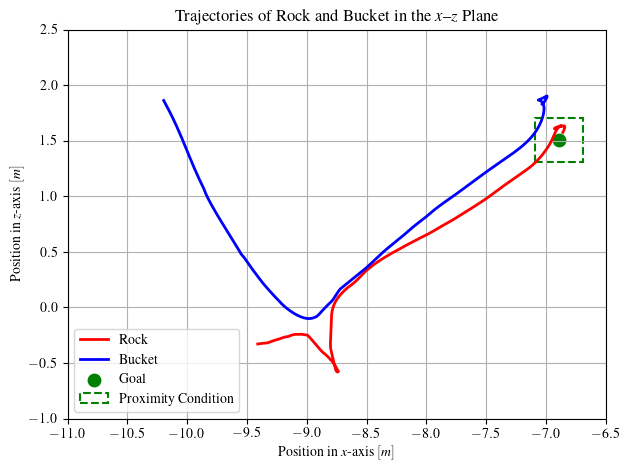

In [649]:
# Plot rock and bucket positions in XZ plane
plt.figure()
plt.plot(rock_positions_x[offset:], rock_positions_z[offset:], label="Rock", color="red", linewidth=2)
plt.plot(bucket_positions_x, bucket_positions_z, label="Bucket", color="blue", linewidth=2)

# # Add target if available
# if not np.all(np.isnan(target_positions_x)) and not np.all(np.isnan(target_positions_z)):
#     plt.plot(target_positions_x, target_positions_z, label="Goal", color="green", linestyle="--", linewidth=2)

# Plot only the final target position if valid
if not np.isnan(target_positions_x[-1]) and not np.isnan(target_positions_z[-1]):
    plt.scatter(target_positions_x[-1], target_positions_z[-1],
                s=80, c='green', label="Goal")
    
    # # Add an empty circle (radius = 0.2) around the goal
    # circle = patches.Circle(
    #     (target_positions_x[-1], target_positions_z[-1]),
    #     radius=0.2,
    #     edgecolor='green',
    #     facecolor='none',
    #     linestyle='--',
    #     linewidth=1.5,
    #     label="Proximity Condition"
    # )
    # plt.gca().add_patch(circle)
    # # plt.gca().set_aspect('equal', adjustable='box')

# # Plot only the final target position if valid
# if not np.isnan(target_positions_x[-1]) and not np.isnan(target_positions_z[-1]):
#     # Plot the square marker for the goal
#     plt.scatter(target_positions_x[-1], target_positions_z[-1],
#                 s=80, c='green', marker='s', label="Goal")
    
    # Calculate the bottom-left corner (x, z) for the square.
    # The center of the square should be the goal position.
    center_x = target_positions_x[-1]
    center_z = target_positions_z[-1]
    side_length = 0.4
    
    # Calculate the bottom-left corner of the square
    bottom_left_x = center_x - (side_length / 2)
    bottom_left_z = center_z - (side_length / 2)
    
    # Add a square (Rectangle patch) with side length 0.2, centered on the goal
    square = patches.Rectangle(
        (bottom_left_x, bottom_left_z), # Bottom-left corner (x, z)
        width=side_length,             # Width (length)
        height=side_length,            # Height (length)
        edgecolor='green',
        facecolor='none',
        linestyle='--',
        linewidth=1.5,
        label="Proximity Condition"
    )
    plt.gca().add_patch(square)
    # plt.gca().set_aspect('equal', adjustable='box')
    
    
# Axis labels
plt.xlabel(r"Position in $x$-axis $[m]$")
plt.ylabel(r"Position in $z$-axis $[m]$")
plt.title(r"Trajectories of Rock and Bucket in the $x–z$ Plane")
plt.legend()
plt.grid(True)
plt.xlim([-11.0, -6.5])
plt.ylim([-1, 2.5])
plt.tight_layout()

# Save and show
plt.savefig(os.path.join(folder,"xz_trajectories.pdf"), format="pdf", bbox_inches="tight")
plt.show()

In [650]:
# # Compute time vector (in seconds)
# timesteps = len(target_positions_x)
# time = np.arange(timesteps) / 60.0  # 60 Hz

# # Plot
# plt.figure(figsize=(10, 5))
# plt.plot(time, target_positions_x, label="Target X", color="green")
# plt.plot(time, target_positions_z, label="Target Z", color="purple")
# plt.plot(time, target_positions_x_in_world, label="Target X World" )
# plt.plot(time, target_positions_z_in_world, label="Target Z world")

# plt.xlabel("Time [s]", fontsize=12)
# plt.ylabel("Position [m]", fontsize=12)
# plt.title("Target Position Over Time", fontsize=13)
# plt.legend()
# plt.grid(True)
# plt.tight_layout()

# # Save figure
# plt.savefig("target_position_over_time.pdf", format="pdf", bbox_inches="tight")
# plt.show()

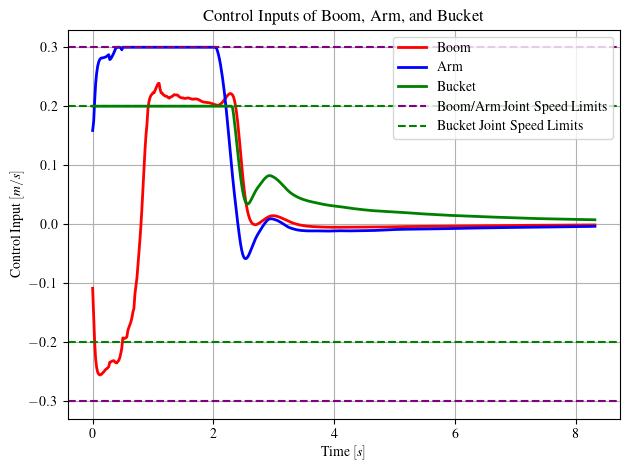

In [651]:
# Plot control inputs for boom, arm, and bucket
timesteps = np.arange(len(action_arm))
time_seconds = timesteps / 60  # 60 Hz = 60 timesteps per second

boom_speed = 0.3
arm_speed = 0.3
bucket_speed = 0.2

plt.figure()
plt.plot(time_seconds, action_arm, label="Boom", color="red", linewidth=2)
plt.plot(time_seconds, action_stick, label="Arm", color="blue", linewidth=2)
plt.plot(time_seconds, action_bucket, label="Bucket", color="green", linewidth=2)

# plt.plot(time_seconds, arm_prismatic_speeds, label="Boom speed", color="green", linewidth=2)
# plt.plot(time_seconds, stick_prismatic_speeds, label="Arm speed", color="green", linewidth=2)
# plt.plot(time_seconds, bucket_prismatic_speeds, label="Bucket speed", color="red", linewidth=2)

# Plot max/min limit lines
plt.axhline(boom_speed, color='purple', linestyle='--', linewidth=1.5, label="Boom/Arm Joint Speed Limits")
plt.axhline(-boom_speed, color='purple', linestyle='--', linewidth=1.5)

plt.axhline(bucket_speed, color='green', linestyle='--', linewidth=1.5, label="Bucket Joint Speed Limits")
plt.axhline(-bucket_speed, color='green', linestyle='--', linewidth=1.5)

# Axis labels and title
plt.xlabel(r"Time $[s]$")
plt.ylabel(r"Control Input $[m/s]$")
plt.title(r"Control Inputs of Boom, Arm, and Bucket")

# Other plot settings
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save and show
plt.savefig(os.path.join(folder,"control_inputs.pdf"), format="pdf", bbox_inches="tight")
plt.show()


In [652]:
# # Time array based on 60 Hz frequency
# timesteps = np.arange(len(arm_prismatic_forces))
# time_seconds = timesteps / 60  # 60 timesteps per second

# # Plot joint forces for boom, arm, and bucket
# plt.figure()
# plt.plot(time_seconds, arm_prismatic_forces / 1e3, label="Boom", color="red", linewidth=2)
# plt.plot(time_seconds, stick_prismatic_forces / 1e3, label="Arm", color="blue", linewidth=2)
# plt.plot(time_seconds, bucket_prismatic_forces / 1e3, label="Bucket", color="green", linewidth=2)

# # Add static lines for ±256 kN
# plt.axhline(y=256, color='gray', linestyle='--', linewidth=1.5, label=r"Joints Force Ranges")
# plt.axhline(y=-256, color='gray', linestyle='--', linewidth=1.5)


# # Axis labels and title
# plt.xlabel(r"Time $[s]$")
# plt.ylabel(r"Force $[kN]$")
# plt.title(r"Joint Forces of Boom, Arm, and Bucket")

# # Other plot settings
# plt.legend()
# plt.grid(True)
# plt.tight_layout()

# # Save and show
# plt.savefig(os.path.join(folder,"joint_forces.pdf"), format="pdf", bbox_inches="tight")
# plt.show()


In [653]:
# # Time vector (assuming 60 Hz sampling rate)
# timesteps = np.arange(len(arm_prismatic_angles))
# time_seconds = timesteps / 60  # Convert to seconds

# boom_pos_max = 0.4
# boom_pos_min = -0.7

# arm_pos_max = 0.8
# arm_pos_min = -0.9

# bucket_pos_max = 0.3
# bucket_pos_min = -1.0

# # Plot joint angles
# plt.figure()
# plt.plot(time_seconds, arm_prismatic_angles, label="Boom", color="red", linewidth=2)
# plt.plot(time_seconds, stick_prismatic_angles, label="Arm", color="blue", linewidth=2)
# plt.plot(time_seconds, bucket_prismatic_angles, label="Bucket", color="green", linewidth=2)

# # Plot max/min limit lines
# # plt.axhline(boom_pos_max, color='red', linestyle='--', linewidth=1.5, label="Boom Joint Position Limit")
# # plt.axhline(boom_pos_min, color='red', linestyle='--', linewidth=1.5)

# # plt.axhline(arm_pos_max, color='blue', linestyle='--', linewidth=1.5, label="Arm Joint Position Limit")
# # plt.axhline(arm_pos_min, color='blue', linestyle='--', linewidth=1.5)

# # plt.axhline(bucket_pos_max, color='green', linestyle='--', linewidth=1.5, label="Bucket Joint Position Limit")
# # plt.axhline(bucket_pos_min, color='green', linestyle='--', linewidth=1.5)

# # Axis labels and title
# plt.xlabel(r"Time $[s]$")
# plt.ylabel(r"Position $[m]$")
# plt.title(r"Joint Postions of Boom, Arm, and Bucket")

# # Other plot settings
# plt.legend()
# plt.grid(True)
# plt.tight_layout()

# # Save and show
# plt.savefig("joint_angles.pdf", format="pdf", bbox_inches="tight")
# plt.show()


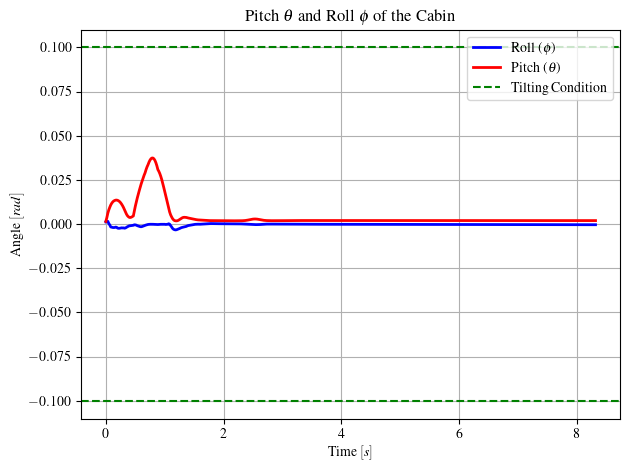

In [654]:
# Time vector (assuming 60 Hz sampling)
timesteps = np.arange(len(chassie_rotation_x))
time_seconds = timesteps / 60  # convert to seconds

# Plot chassis pitch and roll over time
plt.figure()
plt.plot(time_seconds, chassie_rotation_x, label=r"Roll ($\phi$)", color="blue", linewidth=2)
plt.plot(time_seconds, chassie_rotation_y, label=r"Pitch ($\theta$)", color="red", linewidth=2)

# Threshold lines at ±0.1 radians
plt.axhline(y=0.1, color='green', linestyle='--', linewidth=1.5, label="Tilting Condition")
plt.axhline(y=-0.1, color='green', linestyle='--', linewidth=1.5)

# Axis labels and title
plt.xlabel(r"Time $[s]$")
plt.ylabel(r"Angle $[rad]$")
plt.title(r"Pitch $\theta$ and Roll $\phi$ of the Cabin")

# Additional plot settings
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save and show
plt.savefig(os.path.join(folder,"cabin_pitch_roll.pdf"), format="pdf", bbox_inches="tight")
plt.show()
